<a href="https://colab.research.google.com/github/ek-kudi/brain-tumor-detection/blob/main/Brain_Tumor_Detector_GC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#installing dependency
!pip install tf_keras_vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.0 MB/s eta 0:00:00


In [ ]:
 #importing dependencies
import numpy as np
import tensorflow as tf
import cv2
from tensorflow import keras
import sklearn as sk
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import os, shutil


In [ ]:

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install split-folders


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Explanation for the FileNotFoundError in cell BuQCPTvgZX2:
# The folder name 'Brain_Tumor_Datasets' in your Google Drive has a leading space.
# This was observed in the output of cell bad4iP-of_-8: ' Brain_Tumor_Datasets'.
#
# To fix the error, you need to use the exact folder name including the leading space:
# For example, in cell BuQCPTvgZX2, you would change the path to:
# print(os.listdir("/content/drive/MyDrive/ Brain_Tumor_Datasets"))
#
# Alternatively, you can rename the folder in your Google Drive to remove the leading space.

Mounted at /content/drive


In [ ]:
 import os

for folder in os.listdir("/content/drive/MyDrive"):
    print(folder)

Colab Notebooks
Classroom
PHOOLAN DEVI PHOTOS 
FINAL YEAR PROJECT.gdoc
Untitled document (2).gdoc
Untitled document (1).gdoc
What we have dText-Based Emotion Recognition with Python and ML: A Web Application Approachone.gdoc
 Komal important documents 
Cover Letter komal.gdoc
Letter.gdoc
Komal Cover Letter -2.gdoc
 065_Komal_Types of Biomedical Signals and Their Applications in Multimodal Data Analysis.gdoc
Untitled document.gdoc
Multimodal Emotion Detection for Mental-Health Assessment: A Systematic Review .gdoc
paper content .gdoc
Kaisi Yeh Yaariaan Season 01 Episode 61 Boy Interrupted ( 720 X 1280 ).gvid
LIST OF STUDENTS OF IGDTUW .gsheet
DSA striver sheet .gsheet
संपत्ति विभाजन समझौता – केवल फ्लोर व भविष्य निर्माण अधिकार.gdoc
BrainTumorDatasets


In [ ]:
 print(os.listdir("/content/drive/MyDrive/BrainTumorDatasets"))

['dataset_raw', 'dataset']


In [ ]:
import splitfolders

splitfolders.ratio(
  "/content/drive/MyDrive/BrainTumorDatasets/dataset_raw",      # your raw dataset with 4 class folders
    output="/content/drive/MyDrive/BrainTumorDatasets/dataset",  # new dataset with train and val folders
    seed=42,
    ratio=(0.8, 0.2)   # 80% training, 20% testing
)


Copying files: 3162 files [25:45,  2.05 files/s]


In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32


In [ ]:

def preprocess_and_crop(img):
    img = img.astype('uint8')
    img = brain_crop(img)  # your cropping function
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype('float32') / 255.0

In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_and_crop,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_and_crop
)


In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_and_crop,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_and_crop
)

base_path = "/content/drive/MyDrive/BrainTumorDatasets/dataset"

train_data = train_gen.flow_from_directory(
    base_path + "/train",
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    base_path + "/val",
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2535 images belonging to 4 classes.
Found 641 images belonging to 4 classes.


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap.numpy()


In [ ]:
 BASE_DIR = "/content/drive/MyDrive/BrainTumorDatasets/dataset"

TRAIN_DIR = BASE_DIR + "/train"
TEST_DIR  = BASE_DIR + "/val"

IMG_SIZE = 256
BATCH = 32
NUM_CLASSES = 4

In [ ]:
 train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2535 images belonging to 4 classes.
Found 641 images belonging to 4 classes.


In [ ]:
 base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,156 (94.49 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=25
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 91s 936ms/step - accuracy: 0.3371 - loss: 1.4936 - val_accuracy: 0.4462 - val_loss: 1.1738
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 58s 721ms/step - accuracy: 0.3865 - loss: 1.2558 - val_accuracy: 0.4462 - val_loss: 1.1470
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 57s 715ms/step - accuracy: 0.3894 - loss: 1.2223 - val_accuracy: 0.4462 - val_loss: 1.1344
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 56s 695ms/step - accuracy: 0.4235 - loss: 1.1684 - val_accuracy: 0.4493 - val_loss: 1.1177
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 56s 707ms/step - accuracy: 0.4365 - loss: 1.1514 - val_accuracy: 0.4743 - val_loss: 1.0903
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 55s 689ms/step - accuracy: 0.4758 - loss: 1.1309 - val_accuracy: 0.5647 - val_loss: 1.0900
Epoch 7/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 54s 676ms/step - accuracy: 0.4565 - loss: 1.1274 - val_accuracy: 0.5569 - val_loss: 1.0491
Epoch 8/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 703ms/step - accuracy: 0.4963 - loss: 1.1037 - val_accu

In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.7765 - loss: 0.6493
Test Accuracy: 0.7004680037498474


In [ ]:
# ---- FINE TUNING PHASE ----

# 1. Unfreeze last few layers of ResNet50
for layer in base_model.layers[-80:]:
    layer.trainable = True

# 2. Recompile model with small LR
model.compile(
    optimizer=Adam(1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train again (fine-tuning)
history_ft = model.fit(
    train_data,
    validation_data=test_data,
    epochs= 150   # <-- you can increase to 25
)


Epoch 1/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 998ms/step - accuracy: 0.0309 - loss: 25.7691 - val_accuracy: 0.0421 - val_loss: 10.3498
Epoch 2/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 61s 758ms/step - accuracy: 0.0462 - loss: 14.4931 - val_accuracy: 0.0421 - val_loss: 17.6638
Epoch 3/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 60s 748ms/step - accuracy: 0.1431 - loss: 5.6164 - val_accuracy: 0.0421 - val_loss: 10.3392
Epoch 4/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 735ms/step - accuracy: 0.2505 - loss: 2.4222 - val_accuracy: 0.0686 - val_loss: 3.8025
Epoch 5/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 731ms/step - accuracy: 0.4292 - loss: 1.4406 - val_accuracy: 0.3385 - val_loss: 1.4050
Epoch 6/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 739ms/step - accuracy: 0.5274 - loss: 1.1207 - val_accuracy: 0.6225 - val_loss: 0.9989
Epoch 7/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 736ms/step - accuracy: 0.5768 - loss: 0.9955 - val_accuracy: 0.6318 - val_loss: 0.9029
Epoch 8/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 731ms/step - accuracy: 0.5993 - loss: 0.9

In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.7736 - loss: 0.4974
Test Accuracy: 0.8003120422363281


In [ ]:
 def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap, int(class_idx.numpy())


In [ ]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['glioma', 'meningioma', 'no tumor', 'pituitary']


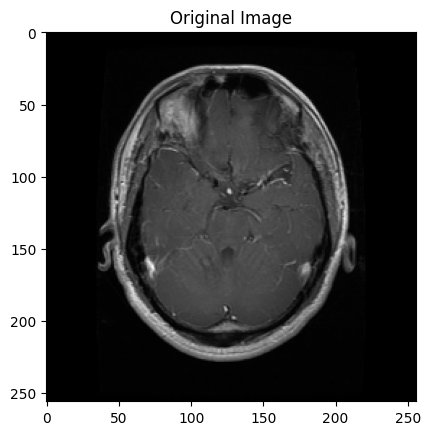

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


Predicted: meningioma
Actual: glioma


In [ ]:
 # pick one test image
img, label = test_data[0][0][0], test_data[0][1][0]

plt.imshow(img)
plt.title("Original Image")
plt.show()

img_array = np.expand_dims(img, axis=0)
heatmap, pred_class = make_gradcam_heatmap(img_array, model)

print("Predicted:", class_names[pred_class])
print("Actual:", class_names[np.argmax(label)])

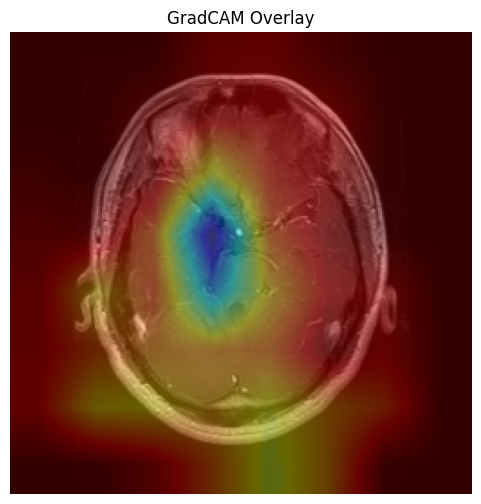

In [ ]:
 # Resize heatmap
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

# Apply colormap
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# --- FIX: Convert both to float32 (0–1 range) ---
img_float = img.astype(np.float32)
heatmap_float = heatmap_color.astype(np.float32) / 255.0

# Blend images
superimposed = cv2.addWeighted(img_float, 0.6, heatmap_float, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(superimposed)
plt.title("GradCAM Overlay")
plt.axis("off")
plt.show()


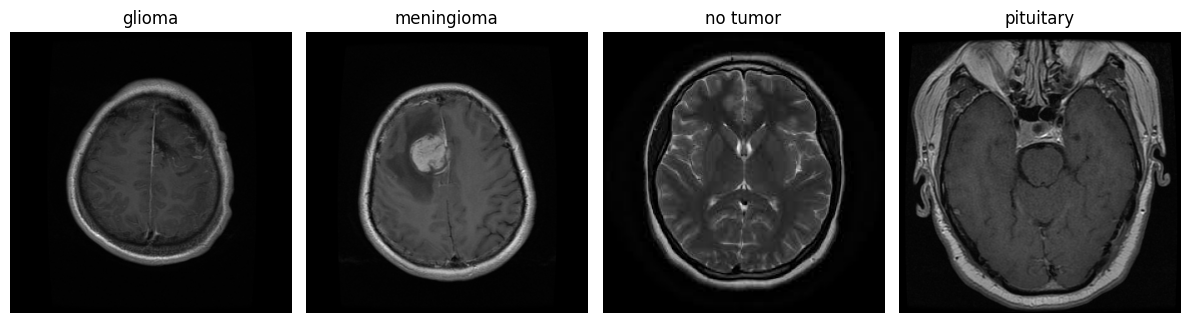

In [ ]:
plt.figure(figsize=(12, 8))

class_names = list(train_data.class_indices.keys())
for i, cls in enumerate(class_names):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    plt.subplot(1, len(class_names), i+1)
    plt.imshow(image.load_img(img_path))
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

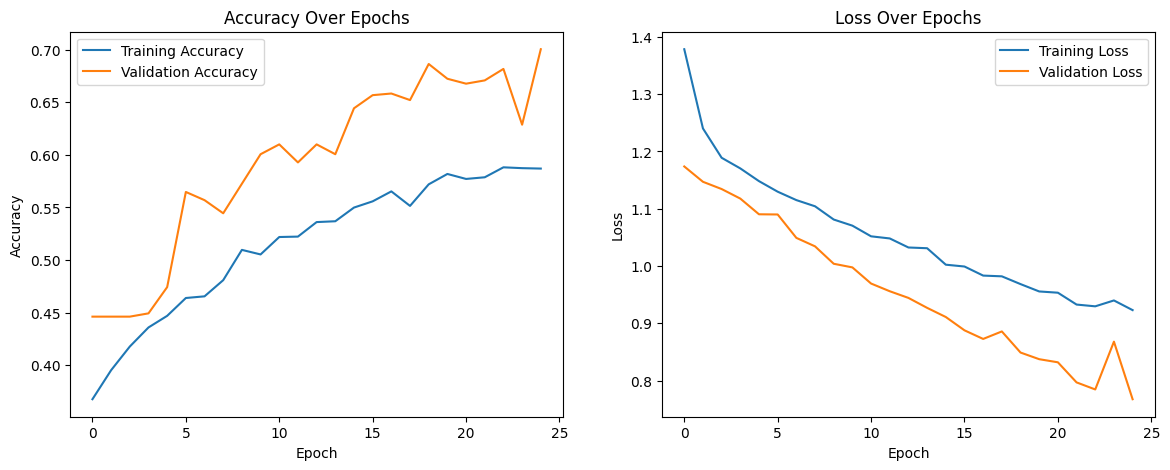

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 576ms/step


<Figure size 800x600 with 0 Axes>

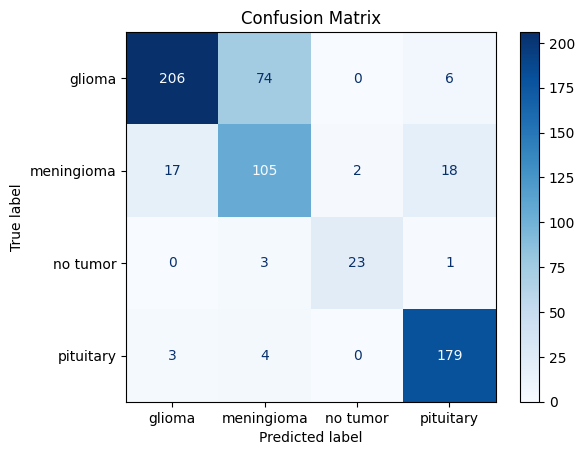

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


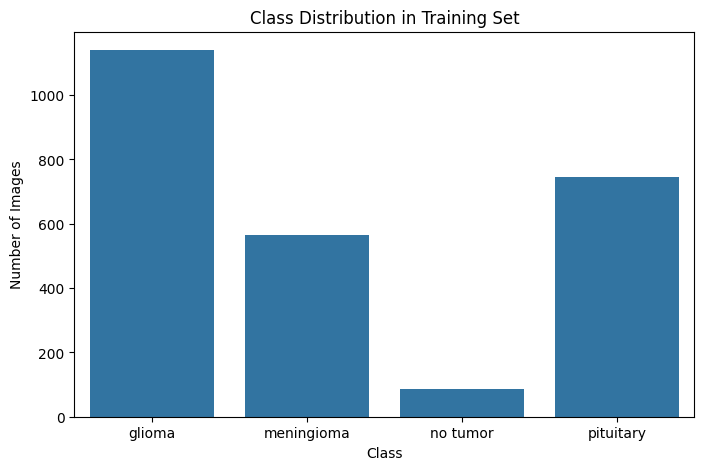

In [ ]:
import seaborn as sns
import pandas as pd

counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in class_names}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
 def display_grad(original_img, heatmap):
    plt.figure(figsize=(15,5))

    # ORIGINAL IMAGE
    plt.subplot(1,3,1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis("off")

    # HEATMAP (RAW)
    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    # OVERLAY (FIXED)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Convert both to the SAME TYPE (float32)
    original_float = original_img.astype(np.float32)
    heatmap_float = heatmap_color.astype(np.float32) / 255.0

    overlay = cv2.addWeighted(original_float, 0.6, heatmap_float, 0.4, 0)

    # DISPLAY OVERLAY
    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


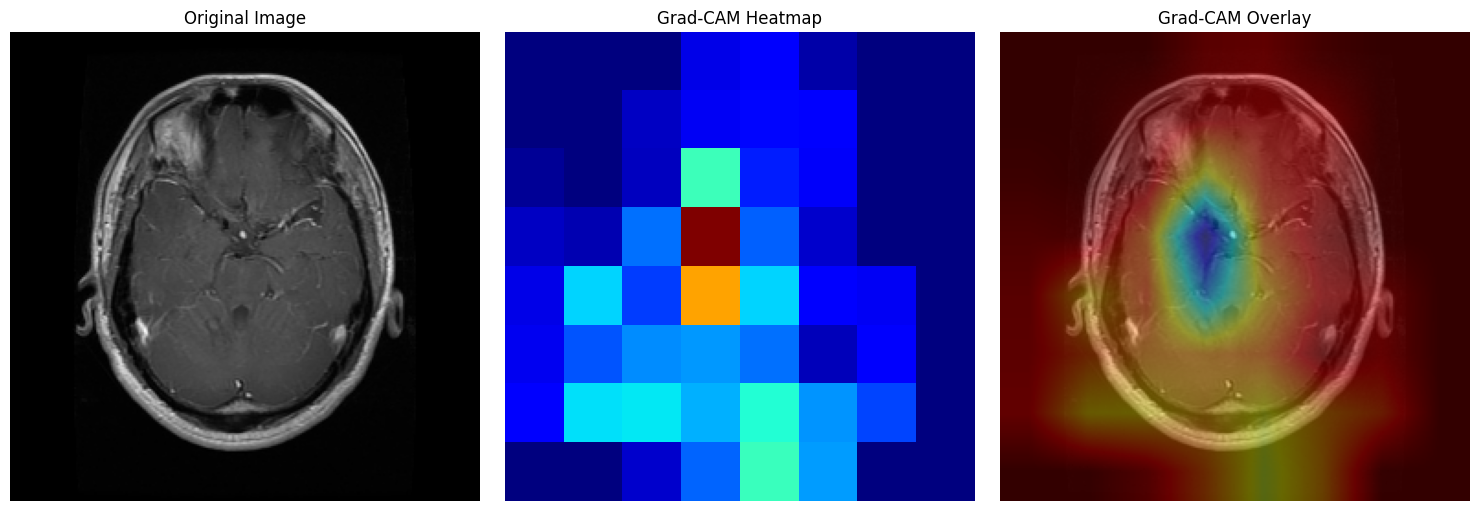

In [ ]:
img, label = test_data[0][0][0], test_data[0][1][0]

img_array = np.expand_dims(img, axis=0)
heatmap, pred_class = make_gradcam_heatmap(img_array, model)

display_grad(img, heatmap)